# Import

In [48]:
import re
import ast
import time
import pandas as pd
from openai import OpenAI
import yaml
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import numpy as np
from bidi.algorithm import get_display

# Configuration

In [49]:
config_path = os.path.join('config', 'config.yaml')
PARAMS = yaml.safe_load(open(config_path, 'r', encoding='utf-8'))

TYPES = ['weapon'] 
CSV_PATH_TEMPLATE = os.path.join('..', PARAMS['CSV_PATH'])  # Contains {type} placeholder
RESULTS_PATH = os.path.join('..', PARAMS['RESULTS_PATH'])
GT_PATH = os.path.join('..', PARAMS['GT_PATH'])
client = OpenAI(api_key=PARAMS['OPENAI_API_KEY'])

# Helper function to get CSV path with type formatted
def get_csv_path(type_name):
    return CSV_PATH_TEMPLATE.format(type=type_name)

ALLOWED = {
    "עובדות המקרה",
    "ראיות לעונש",
    "טיעוני הצדדים",
    "תסקיר שירות מבחן",
    "דיון והכרעה",
    "מידע אחר",
}

# Functions

In [ ]:
def ask_gpt_single(HEADERS: str) -> str:
    """
    Query the model to detect whether 3 main sections appear in the list of headers.
    HEADERS must be a multiline string of unique titles.
    """

    user_prompt = f"""
אתה מומחה לסיווג כותרות מתוך פסקי דין ישראליים.

אתה מקבל רשימה של כותרות מתוך פסק דין ישראלי.  
עליך לזהות האם שלוש הקטגוריות המרכזיות הבאות מופיעות בו:

1. **"עובדות המקרה"**  
   חלק הרקע והתיאור העובדתי: תיאור האירוע,העבירות בהן הורשע הנאשם , כתב האישום, הסדר טיעון, רקע, מבוא וכדומה.
   כותרות אופייניות: "רקע", "הסדר טיעון","פתח דבר","ראשית דבר", "מבוא", "רקע עובדתי","כתב האישום וההליכים", "כללי", "עובדות", "כתב האישום".

2. **"טיעוני הצדדים"**  
   טענות המאשימה, ההגנה או דברי הנאשם.
   כולל עמדות בענישה, טיעונים לעונש, סיכומים, תגובות.
   כותרות אופייניות: "טיעוני המאשימה", "טיעוני ההגנה","טענות", "טענות הצדדים", "הטיעונים לעונש", "דברי הנאשם".

3. **"דיון והכרעה"**  
   הניתוח המשפטי של השופט: מתחם הענישה/עונש, קביעת העונש,מדיניות הענישה, בחינת נסיבות, קביעות.
   כותרות אופייניות: "דיון והכרעה",	"מתחם העונש ההולם", "מתחם העונש","קביעת העונש","קביעת עונשו","העונש המתאים" "מתחם הענישה", "השיקולים","דיון", "העונש", "קביעות", "נסיבות הקשורות", "הנמקה","מדיניות הענישה", "סוף דבר","סיכום", "הכרעה".

על בסיס **רשימת הכותרות בלבד**, החזר האם כל אחת משלוש הקטגוריות הופיעה במסמך.

פורמט החזרה (0 = לא הופיע, 1 = הופיע):

עובדות המקרה – 0/1  
טיעוני הצדדים – 0/1  
דיון והכרעה – 0/1  

הכותרות:
===== BEGIN HEADERS =====
{HEADERS}
===== END HEADERS =====
    """.strip()

    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )

    out = (resp.choices[0].message.content or "").strip()
    out = out.replace('"', '').replace("'", "").strip()

    return out


def parse_llm_headers_output(model_output: str) -> dict:
    """
    Parse output such as:
        עובדות המקרה – 1
        טיעוני הצדדים – 0
        דיון והכרעה – 1
    """

    result = {
        "עובדות המקרה": 0,
        "טיעוני הצדדים": 0,
        "דיון והכרעה": 0
    }

    text = model_output.replace("—", "-").strip()

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        if "עובדות המקרה" in line:
            num = ''.join(ch for ch in line if ch.isdigit())
            if num in ("0", "1"):
                result["עובדות המקרה"] = int(num)

        elif "טיעוני הצדדים" in line:
            num = ''.join(ch for ch in line if ch.isdigit())
            if num in ("0", "1"):
                result["טיעוני הצדדים"] = int(num)

        elif "דיון והכרעה" in line:
            num = ''.join(ch for ch in line if ch.isdigit())
            if num in ("0", "1"):
                result["דיון והכרעה"] = int(num)

    return result


# Run

In [51]:
results_rows = []   # here we accumulate results for all verdicts
for type in TYPES:
    path = rf'CSV_OUTPUT/{type}'
    for file in os.listdir(path):
        file_path = os.path.join(path, file)
        # Load the file
        df = pd.read_csv(file_path)

        # Build unique headers string
        headers_str = "\n".join(df['part'].drop_duplicates().astype(str))

        # Query GPT
        raw_output = ask_gpt_single(headers_str)

        # Parse GPT output
        parsed = parse_llm_headers_output(raw_output)

        print(f"{file}: {parsed}")

        # Save row into results list
        results_rows.append({
            "verdict": file[:-4],  # remove .csv
            "עובדות המקרה": parsed["עובדות המקרה"],
            "טיעוני הצדדים": parsed["טיעוני הצדדים"],
            "דיון והכרעה": parsed["דיון והכרעה"]
        })
    # Save all results to a CSV
    results_df = pd.DataFrame(results_rows)
    results_df.to_csv(os.path.join(RESULTS_PATH,'weapon', 'gpt_headers_detection_results.csv'), index=False)


ME-08-1161-236.csv: {'עובדות המקרה': 0, 'טיעוני הצדדים': 0, 'דיון והכרעה': 1}
ME-09-02-5711-111.csv: {'עובדות המקרה': 1, 'טיעוני הצדדים': 1, 'דיון והכרעה': 1}
ME-09-1010-582.csv: {'עובדות המקרה': 1, 'טיעוני הצדדים': 0, 'דיון והכרעה': 0}
ME-09-657-44.csv: {'עובדות המקרה': 1, 'טיעוני הצדדים': 1, 'דיון והכרעה': 1}
ME-10-05-11982-523.csv: {'עובדות המקרה': 0, 'טיעוני הצדדים': 0, 'דיון והכרעה': 1}
ME-10-05-27955-22.csv: {'עובדות המקרה': 1, 'טיעוני הצדדים': 0, 'דיון והכרעה': 1}
ME-10-06-24817-914.csv: {'עובדות המקרה': 0, 'טיעוני הצדדים': 0, 'דיון והכרעה': 0}
ME-10-07-52268-847.csv: {'עובדות המקרה': 1, 'טיעוני הצדדים': 1, 'דיון והכרעה': 1}
ME-10-11-12302-130.csv: {'עובדות המקרה': 0, 'טיעוני הצדדים': 0, 'דיון והכרעה': 0}
ME-11-01-42326-791.csv: {'עובדות המקרה': 0, 'טיעוני הצדדים': 0, 'דיון והכרעה': 0}
ME-11-03-35646-783.csv: {'עובדות המקרה': 0, 'טיעוני הצדדים': 1, 'דיון והכרעה': 1}
ME-11-04-28317-687.csv: {'עובדות המקרה': 1, 'טיעוני הצדדים': 1, 'דיון והכרעה': 1}
ME-11-04-4986-44.csv: {'עובדות ה

OSError: Cannot save file into a non-existent directory: '..\results\weapon'

In [ ]:
results_df.to_csv(os.path.join(r'C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\weapon', 'gpt_headers_detection_results.csv'), index=False)


results\weapon\gpt_headers_detection_results.csv


# Results

In [ ]:
df_drugs = pd.read_csv(r'C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\drugs\gpt_headers_detection_results.csv')
df_weapon = pd.read_csv(r'C:\Users\user\OneDrive\טל\projects\justice-tal\Classification judgment\results\weapon\gpt_headers_detection_results.csv')
df_all = pd.concat([df_drugs, df_weapon], ignore_index=True)
df = df_all

4560


In [ ]:
# ================================================================
# 1) FIX HEBREW SUPPORT IN MATPLOTLIB
# ================================================================

import arabic_reshaper
from bidi.algorithm import get_display

def fix_hebrew(text: str) -> str:
    """Fix Hebrew text for correct matplotlib display."""
    reshaped = arabic_reshaper.reshape(text)
    bidi = get_display(reshaped)
    return bidi


# ================================================================
# 2) CREATE HEBREW COMBINATION NAME FOR EACH VERDICT
# ================================================================

def combo_name(row):
    parts = []
    if row["עובדות המקרה"] == 1:
        parts.append("עובדות המקרה")
    if row["טיעוני הצדדים"] == 1:
        parts.append("טיעוני הצדדים")
    if row["דיון והכרעה"] == 1:
        parts.append("דיון והכרעה")

    if len(parts) == 0:
        return "ללא אף קטגוריה"

    return " + ".join(parts)

df["combo_name"] = df.apply(combo_name, axis=1)


# ================================================================
# 3) CALCULATE FREQUENCIES & PERCENTAGES
# ================================================================

combo_counts = df["combo_name"].value_counts()
combo_percent = (combo_counts / combo_counts.sum() * 100).round(2)


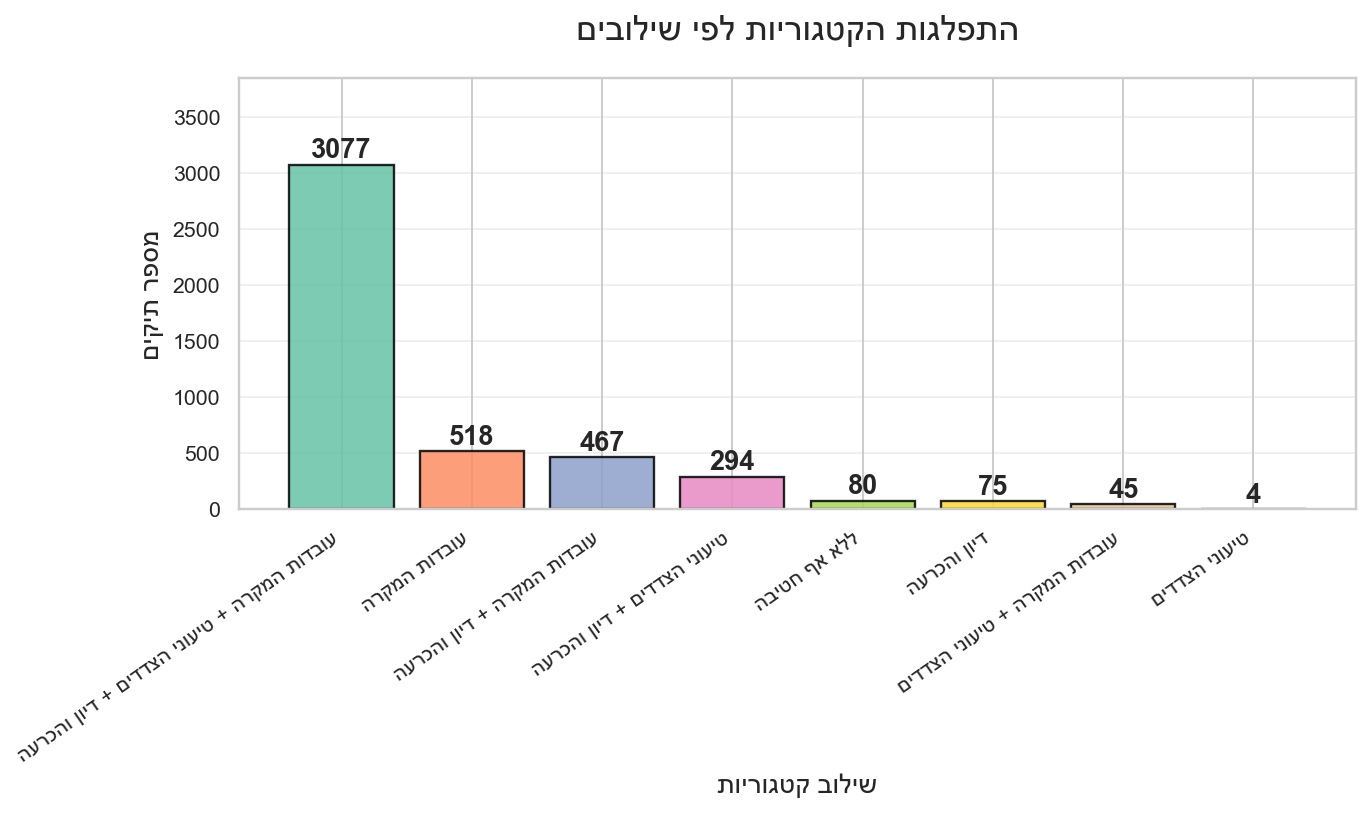

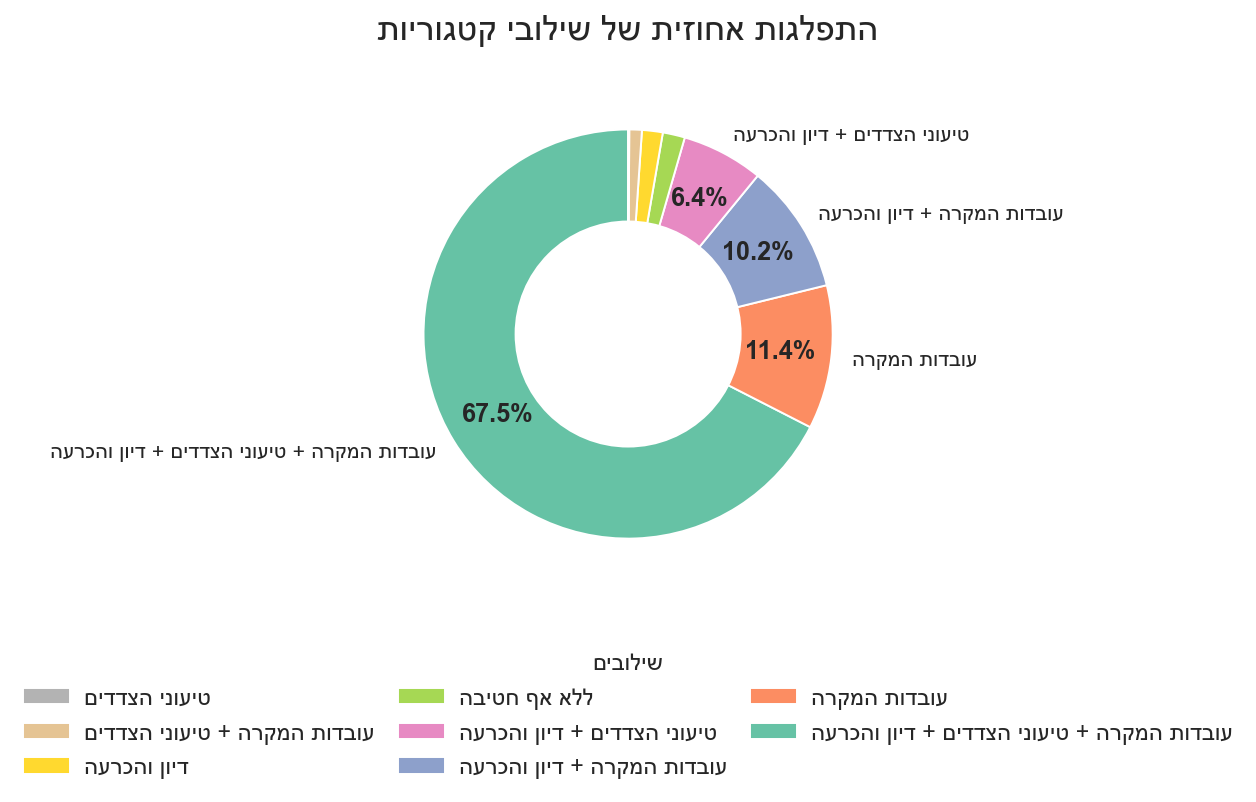

In [70]:
# ================================================================
# BAR & PIE PLOTS — BEAUTIFIED VERSION
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# סטייל מודרני
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.size'] = 13

# צבעים יפים
palette = sns.color_palette("Set2", len(combo_counts))

# ================================================================
# 4) BEAUTIFUL BAR CHART — FREQUENCY OF COMBINATIONS
# ================================================================

plt.figure(figsize=(10,6))

labels = [fix_hebrew(label) for label in combo_counts.index]
values = combo_counts.values

bars = plt.bar(
    labels,
    values,
    color=palette,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.85
)

plt.title(fix_hebrew("התפלגות הקטגוריות לפי שילובים"), fontsize=18, pad=20)
plt.xlabel(fix_hebrew("שילוב קטגוריות"), fontsize=14)
plt.ylabel(fix_hebrew("מספר תיקים"), fontsize=14)

plt.xticks(rotation=35, ha='right')

# ⬅ תיקון הבעיה: הגדלת ציר Y כך שהמספר לא יתנגש
plt.ylim(0, max(values) * 1.25)

# מספרים מעל כל עמודה
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(values) * 0.02,
        f"{int(height)}",
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



# ================================================================
# 5) BEAUTIFUL PIE CHART — PERCENTAGES
# ================================================================

plt.figure(figsize=(10,6))

sizes = combo_percent.values
labels_hebrew = [fix_hebrew(label) for label in combo_percent.index]

# פונקציה לאחוזים רק מעל 2%
def autopct_func(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

# ציור הפאי
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=[lbl if sizes[i] >= 2 else "" for i, lbl in enumerate(labels_hebrew)],
    colors=palette,
    autopct=autopct_func,
    pctdistance=0.75,
    startangle=90
)

plt.setp(autotexts, fontsize=13, fontweight='bold')
plt.title(fix_hebrew("התפלגות אחוזית של שילובי קטגוריות"), fontsize=18, pad=20)

# ======================================================
# ⭐ LEGEND RTL —
# הופכים את הסדר והכיוון להצגה מימין לשמאל
# ======================================================
wedges_rtl = wedges[::-1]
labels_rtl = labels_hebrew[::-1]

plt.legend(
    wedges_rtl,
    labels_rtl,
    title=fix_hebrew("שילובים"),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),   # למטה
    ncol=3,                        # 3 עמודות
    fontsize=12,
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.6
)

# צורת עוגה דונאט
centre_circle = plt.Circle((0,0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()


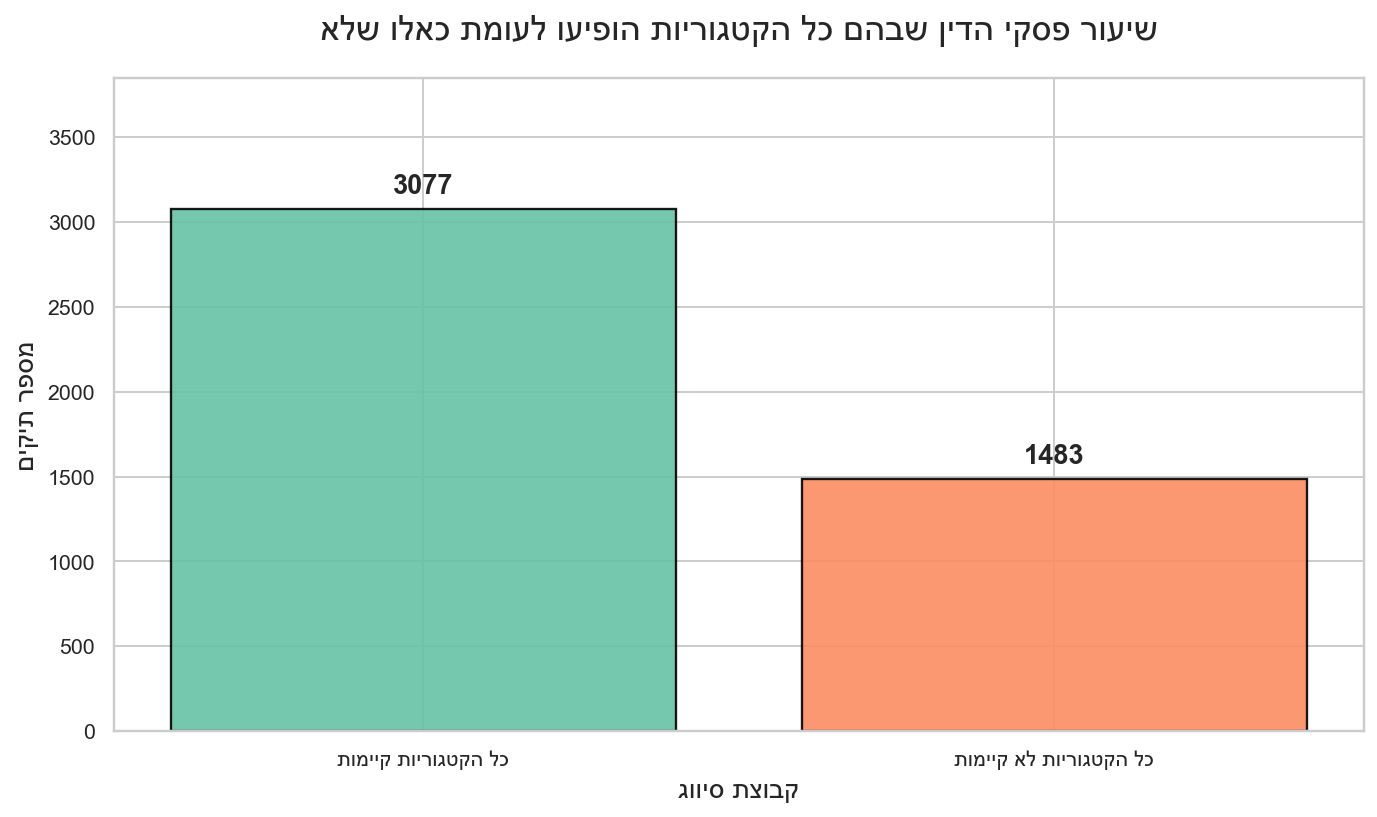

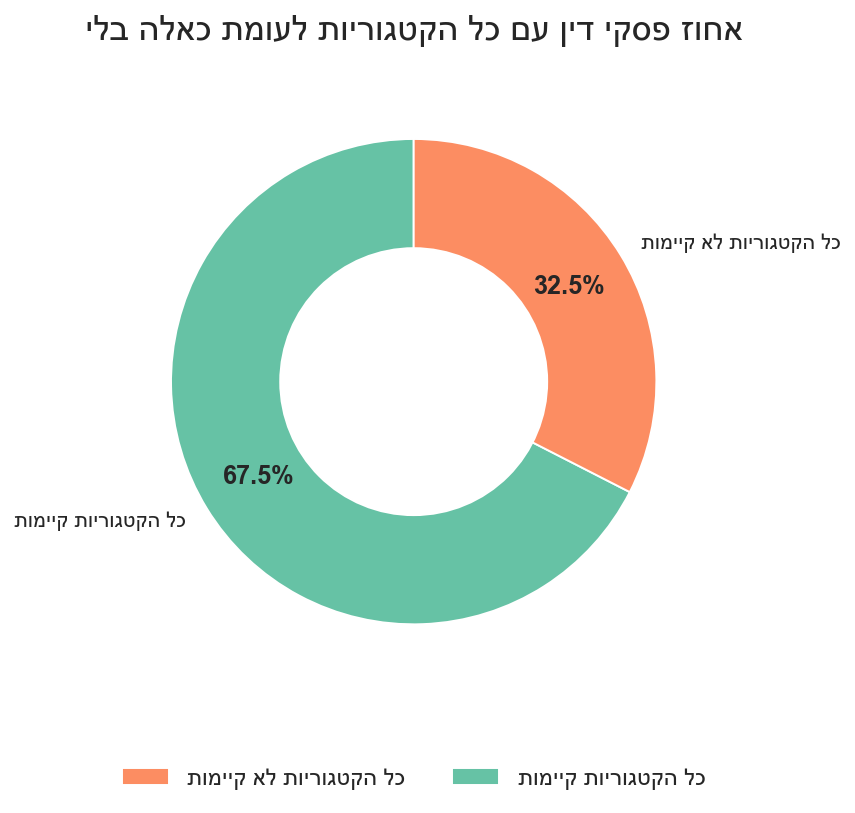

In [69]:
def combo_super_simple(row):
    s = row["עובדות המקרה"] + row["טיעוני הצדדים"] + row["דיון והכרעה"]

    if s == 3:
        return "כל הקטגוריות קיימות"
    else:
        return "כל הקטגוריות לא קיימות"

df["super_simple"] = df.apply(combo_super_simple, axis=1)

simple_counts = df["super_simple"].value_counts()
simple_percent = (simple_counts / simple_counts.sum() * 100).round(2)

# ================================================================
# BAR CHART — SAME SIZE
# ================================================================
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

labels = [fix_hebrew(label) for label in simple_counts.index]
values = simple_counts.values

palette3 = sns.color_palette("Set2", len(labels))

bars = plt.bar(
    labels,
    values,
    color=palette3,
    edgecolor="black",
    linewidth=1.2,
    alpha=0.9
)

plt.title(fix_hebrew("שיעור פסקי הדין שבהם כל הקטגוריות הופיעו לעומת כאלו שלא"), fontsize=18, pad=20)
plt.xlabel(fix_hebrew("קבוצת סיווג"), fontsize=14)
plt.ylabel(fix_hebrew("מספר תיקים"), fontsize=14)

plt.ylim(0, max(values) * 1.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(values)*0.03,
        f"{int(height)}",
        ha='center',
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# ================================================================
# PIE CHART — SAME SIZE
# ================================================================
plt.figure(figsize=(10,6))   # 👈 עכשיו אותו הגודל כמו הבר-צ'ארט

labels_he = [fix_hebrew(label) for label in simple_counts.index]
sizes = simple_percent.values

def autopct_func(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=[lbl if sizes[i] >= 2 else "" for i, lbl in enumerate(labels_he)],
    colors=palette3,
    autopct=autopct_func,
    pctdistance=0.75,
    startangle=90
)

plt.setp(autotexts, fontsize=13, fontweight='bold')
plt.title(fix_hebrew("אחוז פסקי דין עם כל הקטגוריות לעומת כאלה בלי"), fontsize=18, pad=20)

plt.legend(
    wedges[::-1],
    labels_he[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    fontsize=12,
    frameon=False
)

centre_circle = plt.Circle((0,0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()
